In [1]:
# Imports
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import time
from scipy.stats import norm

from nested_dr_kpt import NestedDRKPT
from dsprites_environment import generate_dsprites_data, recompute_weights

In [2]:
def run_type1_error(sample_sizes, num_experiments, name_folder):
    """Type I error (Delta=0) vs sample size. Saves one CSV per n."""
    os.makedirs(name_folder, exist_ok=True)
    test = NestedDRKPT(state_kernel="rbf", cross_fit=True)
    for n in sample_sizes:
        p_values = np.zeros(num_experiments)
        stats    = np.zeros(num_experiments)
        times    = np.zeros(num_experiments)
        for seed in range(num_experiments):
            data = generate_dsprites_data(n, Delta=0.0, seed=seed)
            try:
                t0 = time.time()
                result = test.test(data)
                times[seed] = time.time() - t0
                p_values[seed] = result["pval"]
                stats[seed]    = result["stat"]
            except Exception as e:
                print(f"  n={n} seed={seed}: {e}")
                p_values[seed] = stats[seed] = times[seed] = np.nan
        fname = f"{name_folder}/dsprites_type1_ns{n}.csv"
        pd.DataFrame({"p_value": p_values, "stat": stats, "time": times}).to_csv(fname, index=False)
        rej = np.nanmean(p_values < 0.05)
        print(f"n={n:4d}  rejection rate={rej:.3f}  saved: {fname}")


def run_power(n, deltas, num_experiments, name_folder):
    """Power (Delta > 0) vs policy shift Delta at fixed n. Saves one CSV per Delta."""
    os.makedirs(name_folder, exist_ok=True)
    test = NestedDRKPT(state_kernel="rbf", cross_fit=True)
    for Delta in deltas:
        p_values = np.zeros(num_experiments)
        stats    = np.zeros(num_experiments)
        times    = np.zeros(num_experiments)
        for seed in range(num_experiments):
            data = generate_dsprites_data(n, Delta=Delta, seed=seed)
            try:
                t0 = time.time()
                result = test.test(data)
                times[seed] = time.time() - t0
                p_values[seed] = result["pval"]
                stats[seed]    = result["stat"]
            except Exception as e:
                print(f"  Delta={Delta:.2f} seed={seed}: {e}")
                p_values[seed] = stats[seed] = times[seed] = np.nan
        fname = f"{name_folder}/dsprites_power_delta{Delta:.2f}.csv"
        pd.DataFrame({"p_value": p_values, "stat": stats, "time": times}).to_csv(fname, index=False)
        rej = np.nanmean(p_values < 0.05)
        print(f"Delta={Delta:.2f}  rejection rate={rej:.3f}  saved: {fname}")


def run_misspecification_grid(n, num_experiments, name_folder):
    """
    4-way DR misspecification grid at Delta=0 (null). Saves one CSV per scenario.

    Scenario 1: correct propensity (logging_coeff=0.3) + correct kernel (rbf)
    Scenario 2: correct propensity                     + wrong kernel   (linear)
    Scenario 3: wrong propensity   (logging_coeff=0.0) + correct kernel (rbf)
    Scenario 4: wrong propensity                       + wrong kernel   (linear)
    """
    os.makedirs(name_folder, exist_ok=True)
    test_rbf    = NestedDRKPT(state_kernel="rbf",    cross_fit=True)
    test_linear = NestedDRKPT(state_kernel="linear", cross_fit=True)

    scenarios = {
        1: (False, test_rbf),
        2: (False, test_linear),
        3: (True,  test_rbf),
        4: (True,  test_linear),
    }
    results = {s: {"p_value": [], "stat": [], "time": []} for s in scenarios}

    for seed in range(num_experiments):
        data_true = generate_dsprites_data(n, Delta=0.0, seed=seed)
        data_wrong = recompute_weights(data_true, logging_coeff_wrong=0.0)
        for s, (use_wrong_prop, test) in scenarios.items():
            data = data_wrong if use_wrong_prop else data_true
            try:
                t0 = time.time()
                result = test.test(data)
                elapsed = time.time() - t0
                results[s]["p_value"].append(result["pval"])
                results[s]["stat"].append(result["stat"])
                results[s]["time"].append(elapsed)
            except Exception as e:
                print(f"  scenario={s} seed={seed}: {e}")
                results[s]["p_value"].append(np.nan)
                results[s]["stat"].append(np.nan)
                results[s]["time"].append(np.nan)

    for s in scenarios:
        fname = f"{name_folder}/misspec_scenario{s}.csv"
        pd.DataFrame(results[s]).to_csv(fname, index=False)
        rej = np.nanmean(np.array(results[s]["p_value"]) < 0.05)
        print(f"Scenario {s}  rejection rate={rej:.3f}  saved: {fname}")

In [3]:
FOLDER = "results/dsprites"

# Type I error: rejection rate vs sample size (Delta=0)
run_type1_error(
    sample_sizes=list(range(100, 550, 50)),
    num_experiments=100,
    name_folder=FOLDER,
)

n= 100  rejection rate=0.100  saved: results/dsprites/dsprites_type1_ns100.csv
n= 150  rejection rate=0.140  saved: results/dsprites/dsprites_type1_ns150.csv
n= 200  rejection rate=0.080  saved: results/dsprites/dsprites_type1_ns200.csv
n= 250  rejection rate=0.040  saved: results/dsprites/dsprites_type1_ns250.csv
n= 300  rejection rate=0.080  saved: results/dsprites/dsprites_type1_ns300.csv
n= 350  rejection rate=0.060  saved: results/dsprites/dsprites_type1_ns350.csv
n= 400  rejection rate=0.030  saved: results/dsprites/dsprites_type1_ns400.csv
n= 450  rejection rate=0.030  saved: results/dsprites/dsprites_type1_ns450.csv
n= 500  rejection rate=0.070  saved: results/dsprites/dsprites_type1_ns500.csv


In [4]:
# Power: rejection rate vs policy shift Delta (n=300)
run_power(
    n=300,
    deltas=np.round(np.arange(0.2, 1.6, 0.2), 2).tolist(),
    num_experiments=100,
    name_folder=FOLDER,
)

Delta=0.20  rejection rate=0.490  saved: results/dsprites/dsprites_power_delta0.20.csv
Delta=0.40  rejection rate=0.930  saved: results/dsprites/dsprites_power_delta0.40.csv
Delta=0.60  rejection rate=0.990  saved: results/dsprites/dsprites_power_delta0.60.csv
Delta=0.80  rejection rate=0.990  saved: results/dsprites/dsprites_power_delta0.80.csv
Delta=1.00  rejection rate=0.990  saved: results/dsprites/dsprites_power_delta1.00.csv
Delta=1.20  rejection rate=0.990  saved: results/dsprites/dsprites_power_delta1.20.csv
Delta=1.40  rejection rate=0.990  saved: results/dsprites/dsprites_power_delta1.40.csv


In [5]:
# Misspecification grid: 4 scenarios at Delta=0, n=300
run_misspecification_grid(
    n=300,
    num_experiments=100,
    name_folder=FOLDER,
)

Scenario 1  rejection rate=0.080  saved: results/dsprites/misspec_scenario1.csv
Scenario 2  rejection rate=0.050  saved: results/dsprites/misspec_scenario2.csv
Scenario 3  rejection rate=0.070  saved: results/dsprites/misspec_scenario3.csv
Scenario 4  rejection rate=0.030  saved: results/dsprites/misspec_scenario4.csv


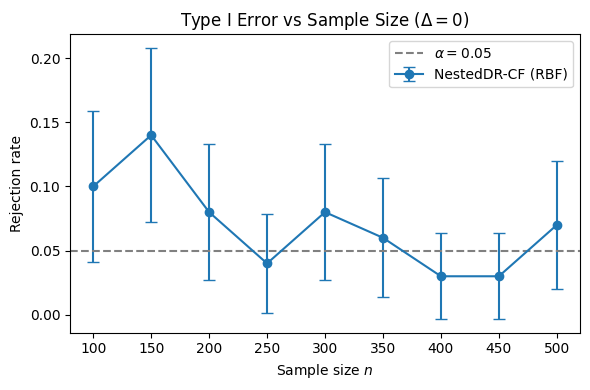

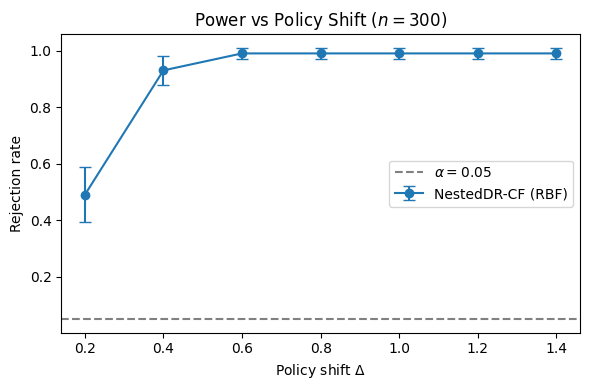

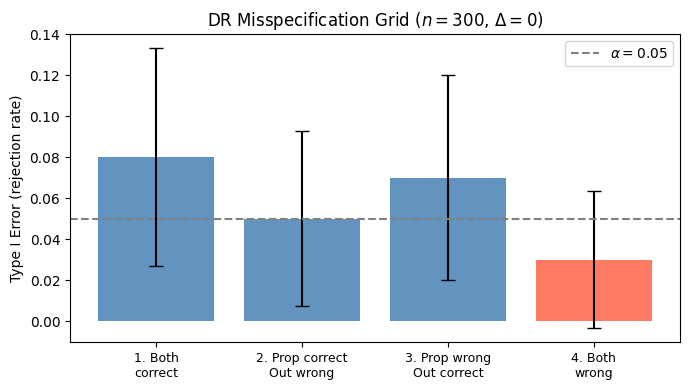

In [6]:
# --- Plots ---

PLOTS = "plots/dsprites"
os.makedirs(PLOTS, exist_ok=True)


def _ci(rej_rate, n_exp, z=1.96):
    """Wilson-ish CI half-width for a proportion."""
    return z * np.sqrt(rej_rate * (1 - rej_rate) / n_exp)


# --- Figure 1: Type I error vs n ---
ns = list(range(100, 550, 50))
rates, errs = [], []
for n in ns:
    df = pd.read_csv(f"{FOLDER}/dsprites_type1_ns{n}.csv")
    r = np.nanmean(df["p_value"] < 0.05)
    rates.append(r)
    errs.append(_ci(r, (~df["p_value"].isna()).sum()))

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(ns, rates, yerr=errs, fmt="o-", capsize=4, label="NestedDR-CF (RBF)")
ax.axhline(0.05, color="grey", linestyle="--", label=r"$\alpha=0.05$")
ax.set_xlabel("Sample size $n$")
ax.set_ylabel("Rejection rate")
ax.set_title("Type I Error vs Sample Size ($\\Delta=0$)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS}/type1_error.png", dpi=150)
plt.show()


# --- Figure 2: Power vs Delta ---
deltas = np.round(np.arange(0.2, 1.6, 0.2), 2)
rates, errs = [], []
for d in deltas:
    df = pd.read_csv(f"{FOLDER}/dsprites_power_delta{d:.2f}.csv")
    r = np.nanmean(df["p_value"] < 0.05)
    rates.append(r)
    errs.append(_ci(r, (~df["p_value"].isna()).sum()))

fig, ax = plt.subplots(figsize=(6, 4))
ax.errorbar(deltas, rates, yerr=errs, fmt="o-", capsize=4, label="NestedDR-CF (RBF)")
ax.axhline(0.05, color="grey", linestyle="--", label=r"$\alpha=0.05$")
ax.set_xlabel(r"Policy shift $\Delta$")
ax.set_ylabel("Rejection rate")
ax.set_title("Power vs Policy Shift ($n=300$)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS}/power_vs_delta.png", dpi=150)
plt.show()


# --- Figure 3: Misspecification grid bar chart ---
scenario_labels = [
    "1. Both\ncorrect",
    "2. Prop correct\nOut wrong",
    "3. Prop wrong\nOut correct",
    "4. Both\nwrong",
]
rates, errs = [], []
for s in range(1, 5):
    df = pd.read_csv(f"{FOLDER}/misspec_scenario{s}.csv")
    r = np.nanmean(df["p_value"] < 0.05)
    rates.append(r)
    errs.append(_ci(r, (~df["p_value"].isna()).sum()))

fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(4)
bars = ax.bar(x, rates, yerr=errs, capsize=5, color=["steelblue", "steelblue", "steelblue", "tomato"],
              alpha=0.85)
ax.axhline(0.05, color="grey", linestyle="--", label=r"$\alpha=0.05$")
ax.set_xticks(x)
ax.set_xticklabels(scenario_labels, fontsize=9)
ax.set_ylabel("Type I Error (rejection rate)")
ax.set_title("DR Misspecification Grid ($n=300$, $\\Delta=0$)")
ax.legend()
plt.tight_layout()
plt.savefig(f"{PLOTS}/misspec_grid.png", dpi=150)
plt.show()